# TMDB Movie Data Analysis using Sparl and APIs

## Project Overview

This project challenges you to build a movie data analysis pipeline using Python and Pandas.

You will fetch movie-related data from an API, clean and transform the dataset, and implement key performance indicators (KPIs).

This is not a group project, meaning you will design the workflow, structure the analysis, and implement the required calculations independently.

## Project Objectives

   - API Data Extraction: Fetch movie data from a movie database API.

   - Data Cleaning & Transformation: Process and structure the data for analysis.

   - Exploratory Data Analysis (EDA): Perform an initial exploration to understand trends.

   - Advanced Filtering & Ranking: Identify the best and worst movies based on financial and popularity metrics.

   - Franchise & Director Analysis: Assess how franchises and directors perform over time.

   - Visualization & Insights: Present key findings using visualizations.


In [1]:
from __future__ import annotations


from pathlib import Path
import sys
from typing import cast

project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

from pyspark.sql import SparkSession, DataFrame, functions as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    get_movies_df_from_ids,
    clean_movie_df,
    compute_finances,
    rank_movies
)

### Step 1: Fetch Movie Data from API

   - Choose a movie database API (e.g., TMDb).

   - Fetch movies with ID:

   - movie_id = [0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259, 99861, 284054, 12445, 181808, 330457, 351286, 109445, 321612, 260513]

   - Store the data as a Pandas DataFrame.

   - NB: Read the API documentation to understand the nature of the data and how it's organized.


In [2]:
spark = (
    SparkSession.builder
    .appName("tmdb_pipeline")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/15 11:11:25 WARN Utils: Your hostname, ahk, resolves to a loopback address: 127.0.1.1; using 192.168.1.167 instead (on interface wlan0)
26/04/15 11:11:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/15 11:11:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Download movies
MOVIE_IDS = [
    0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259, 99861, 284054, 12445, 181808, 330457, 351286,
    109445, 321612,260513,476161, 5, 1180681, 9741, 7183, 18, 2069, 1035803, 1035806, 1024546, 1571, 1572, 1573, 761892,
    46122, 562, 5172, 774714, 63, 59967, 278086, 1507910, 2122, 2124, 9292, 1113682, 32855, 39514, 95, 30815, 3172, 718949,
    241254, 9319, 136296, 3179, 9333, 50298, 77948, 8324, 8838, 531593, 9356, 17043, 4244, 480404, 280217, 9882, 1414301,
    9374, 2207, 38560, 1637024, 24226, 10403, 163, 686245, 680, 137896, 234158, 486068, 186, 187, 454330, 189, 23742, 12479,
    85693, 986824, 83666, 118483, 169173, 20694, 395990, 4824, 894169, 14043, 181471, 384737, 285923, 82150, 745, 8944,
    872177, 504562, 641790, 9471, 18176, 584962, 7944, 921353, 1645833, 921355, 921360, 9494, 326425, 763164, 1265440,
    7457, 146216, 542508, 883502, 139567, 32047, 651571, 345915, 479040, 11074, 11593, 345934, 84305, 1528146, 916821,
    47964, 7518, 9567, 10592, 31586, 1460067, 30565, 12647, 381288, 360295, 126314, 829799, 787310, 72559, 843633, 9586,
    864116, 25975, 693113, 826749, 76163, 135051, 918, 1533851, 145308, 681887, 450465, 552865, 43939, 714666, 1049516,
    9644, 70586, 27578, 12220, 410554, 132542, 1146302, 766907, 153538, 31683, 742341, 28614, 1992, 307663, 75736, 253414,
    1127399, 2026, 63472, 359412, 19959, 536056, 724989, 290304, 5, 66566, 22538, 67083, 1588237, 278542, 62488, 24, 754721,
    1502241, 761892, 99368, 185896, 46122, 374317, 20013, 1173040, 539199, 1261119, 480834, 35907, 124998, 342091, 79, 1623134,
    1228384, 1341540, 281702, 68718, 114287, 1071215, 58492, 1058940, 962192, 245906, 97430, 455319, 533658, 1690, 1691, 458399,
    171168, 986277, 680, 92850, 1567925, 184, 187, 20668, 1598142, 1002181, 1110728, 986824, 1457866, 414419, 13025,
    285923, 63206, 594158, 413422, 1418478, 241, 1145586, 755, 443129, 515834, 36606, 1645833, 56591, 199951, 225554, 8982,
    28447, 166183, 333106, 224562, 61752, 44345, 289083, 319, 12095, 16194, 44535, 144708, 13637, 1445188, 101204, 466272,
    273248, 540003, 1242980, 1460067, 1088359, 631143, 1005428, 393076, 1629557, 288122, 1145722, 833916, 8068, 393, 56224,
    19361, 149922, 396194, 1310632, 20910, 82865, 399794, 1065395, 264117, 1146302, 1010623, 1991, 1992, 339403, 1390028,
    9678, 12241, 353746, 102868, 161239, 19416, 85984, 16869, 10213, 500, 1569780, 13300, 599031, 854521, 464890, 507
]


df, failed = await get_movies_df_from_ids(spark, movie_ids=MOVIE_IDS)

if failed:
    print(f"\nThe following IDs could not be fetched: {failed}")

if df is None:
    print("No data found for the specified movie IDs.")

Fetching Movies: 100%|██████████| 1/1 [00:21<00:00, 21.35s/it]


The following IDs could not be fetched: [0]


In [4]:
# Cast to avoid type warning
df = cast(DataFrame, df)

In [5]:
df.show(10)

26/04/15 11:11:57 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------+-----+--------------------+---------------------+------+--------------------+--------------------+---------+-----------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+------------+-------------+-------+--------------------+--------+--------------------+--------------------+-----+------------+----------+--------------------+--------------------+
|    id|adult|       backdrop_path|belongs_to_collection|budget|              genres|            homepage|  imdb_id|original_language|      original_title|            overview|popularity|         poster_path|production_companies|production_countries|release_date|      revenue|runtime|    spoken_languages|  status|             tagline|               title|video|vote_average|vote_count|                cast|                crew|
+------+-----+--------------------+---------------------+------+--------------------+--------------------+---------+-----------------+------

## Step 2: Data Cleaning and Preprocessing

### Data Preparation & Cleaning

   1. Drop irrelevant columns: ['adult', 'imdb_id', 'original_title', 'video', 'homepage'].

   2. Evaluate JSON-like columns (['belongs_to_collection', 'genres', 'production_countries', 'production_companies', 'spoken_languages']).

   3. Extract and clean key data points:

        - Collection name (belongs_to_collection)

        - Genre names (genres → separate multiple genres with "|").

        - Spoken languages (spoken_languages → separate with "|").

        - Production countries (production_countries → separate with "|").

        - Production companies (production_companies → separate with "|").

   4. Inspect extracted columns using value_counts() to identify anomalies.

Handling Missing & Incorrect Data


   5. Convert column datatypes:

        'budget', 'id', 'popularity' → Numeric (set invalid values to NaN).
        'release_date' → Convert to datetime.
        etc

   6. Replace unrealistic values:

        Budget/Revenue/Runtime $= 0$ → Replace with NaN or infer from similar movies.
        Convert 'budget' and 'revenue' to million USD.
        Movies with vote_count = 0 → Analyze their vote_average and adjust accordingly.
        'overview' and 'tagline' → Replace known placeholders (e.g., 'No Data') with NaN.

   7. Remove duplicates and drop rows with unknown 'id' or 'title'.

   8. Keep only rows where at least 10 columns have non-NaN values.

   9. Filter to include only 'Released' movies, then drop 'status'.

**Reorder & Finalize DataFrame**

   10. Reorder columns:

   ```
    ['id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection', 'original_language',
        'budget_musd', 'revenue_musd', 'production_companies', 'production_countries', 'vote_count', 'vote_average',
        'popularity', 'runtime', 'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 'crew_size']
   ```
   11. Reset index.


In [6]:
# Define the columns to drop
cols_to_drop = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']

# Define the final column order as per instructions
final_column_order = [
    'id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection',
    'original_language', 'budget_musd', 'revenue_musd', 'production_companies',
    'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime',
    'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 'crew_size'
]

# Cleaning pipeline using chaining
df_cleaned  = clean_movie_df(df, cols_to_drop=cols_to_drop, final_column_order=final_column_order)

In [7]:
df_cleaned.show(10, truncate=False)

+---+-------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------+------------+-----------------------------------------+---------------------+-----------------+-----------+------------+------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------+----------+------------+----------+-------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Step 3: KPI Implementation & Analysis

### Identify the Best/Worst Performing Movies

   1. Filter and rank movies based on:

        - Highest Revenue

        - Highest Budget

        - Highest Profit (Revenue - Budget)

        - Lowest Profit (Revenue - Budget)

        - Highest ROI (Revenue / Budget) (only movies with Budget $\ge 10M$)

        - Lowest ROI (only movies with Budget $\ge 10M$)

        - Most Voted Movies

        - Highest Rated Movies (only movies with $\ge 10$ votes)

        - Lowest Rated Movies (only movies with $\ge 10$ votes)

        - Most Popular Movies

   - Define a User-Defined Function (UDF) to streamline ranking operations.

Advanced Movie Filtering & Search Queries

   3. Filter the dataset for specific queries:

        - Search 1: Find the best-rated Science Fiction Action movies starring Bruce Willis (sorted by Rating - highest to lowest).
        - Search 2: Find movies starring Uma Thurman, directed by Quentin Tarantino (sorted by runtime - shortest to longest).

#### Franchise vs. Standalone Movie Performance

   4. Compare movie franchises (belongs_to_collection) vs. standalone movies in terms of:

        - Mean Revenue
        - Median ROI
        - Mean Budget Raised
        - Mean Popularity
        - Mean Rating

#### Most Successful Franchises & Directors

   5. Find the Most Successful Movie Franchises based on:

        - Total number of movies in franchise
        - Total & Mean Budget
        - Total & Mean Revenue
        - Mean Rating

   6. Find the Most Successful Directors based on:

        - Total Number of Movies Directed
        - Total Revenue
        - Mean Rating


In [8]:
# Add Profit and ROI columns to our cleaned dataframe
df_final = compute_finances(df_cleaned)

In [9]:
df_final.show(10, truncate=False)

+---+-------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------+------------+-----------------------------------------+---------------------+-----------------+-----------+------------+------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------+----------+------------+----------+-------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [10]:
# 1. Highest Revenue
top_revenue = rank_movies(df_final, 'revenue_musd')
top_revenue.show(truncate=False)

+----------------------------+------------+----------+-----------+
|title                       |revenue_musd|vote_count|budget_musd|
+----------------------------+------------+----------+-----------+
|Avatar                      |2923.706    |33763     |237.0      |
|Avengers: Endgame           |2799.439    |27486     |356.0      |
|Titanic                     |2264.162    |26987     |200.0      |
|Star Wars: The Force Awakens|2068.224    |20423     |245.0      |
|Avengers: Infinity War      |2052.415    |31722     |300.0      |
|Jurassic World              |1671.537    |21455     |150.0      |
|The Lion King               |1662.021    |10695     |260.0      |
|The Avengers                |1518.816    |37164     |220.0      |
|Furious 7                   |1515.4      |11214     |190.0      |
|Frozen II                   |1453.683    |10225     |150.0      |
+----------------------------+------------+----------+-----------+



In [11]:
# 2. Highest Budget
top_budget = rank_movies(df_final, 'budget_musd')
top_budget.show(truncate=False)

+----------------------------+-----------+----------+------------+
|title                       |budget_musd|vote_count|revenue_musd|
+----------------------------+-----------+----------+------------+
|Avengers: Endgame           |356.0      |27486     |2799.439    |
|Avengers: Infinity War      |300.0      |31722     |2052.415    |
|Star Wars: The Last Jedi    |300.0      |16221     |1332.699    |
|The Lion King               |260.0      |10695     |1662.021    |
|Star Wars: The Force Awakens|245.0      |20423     |2068.224    |
|Avatar                      |237.0      |33763     |2923.706    |
|Avengers: Age of Ultron     |235.0      |24274     |1405.404    |
|The Avengers                |220.0      |37164     |1518.816    |
|Titanic                     |200.0      |26987     |2264.162    |
|Incredibles 2               |200.0      |13601     |1243.226    |
+----------------------------+-----------+----------+------------+



In [12]:
# 3. Highest Profit
top_profit = rank_movies(df_final, 'profit_musd')
top_profit.show(truncate=False)

+----------------------------+-----------+----------+-----------+------------+
|title                       |profit_musd|vote_count|budget_musd|revenue_musd|
+----------------------------+-----------+----------+-----------+------------+
|Avatar                      |2686.706   |33763     |237.0      |2923.706    |
|Avengers: Endgame           |2443.439   |27486     |356.0      |2799.439    |
|Titanic                     |2064.162   |26987     |200.0      |2264.162    |
|Star Wars: The Force Awakens|1823.224   |20423     |245.0      |2068.224    |
|Avengers: Infinity War      |1752.415   |31722     |300.0      |2052.415    |
|Jurassic World              |1521.537   |21455     |150.0      |1671.537    |
|The Lion King               |1402.021   |10695     |260.0      |1662.021    |
|Furious 7                   |1325.4     |11214     |190.0      |1515.4      |
|Frozen II                   |1303.683   |10225     |150.0      |1453.683    |
|The Avengers                |1298.816   |37164     

In [13]:
# 4. Lowest Profit (Worst Financial Performance)
worst_profit = rank_movies(df_final, 'profit_musd', ascending=True)
worst_profit.show(truncate=False)

+----------------------------------+-----------+----------+-----------+------------+
|title                             |profit_musd|vote_count|budget_musd|revenue_musd|
+----------------------------------+-----------+----------+-----------+------------+
|Kill Bill: The Whole Bloody Affair|-49.194    |1203      |55.0       |5.806       |
|Hudson Hawk                       |-47.782    |1120      |65.0       |17.218      |
|Hart's War                        |-37.713    |1042      |70.0       |32.287      |
|Grindhouse                        |-34.578    |1860      |60.0       |25.422      |
|North                             |-32.817    |277       |40.0       |7.183       |
|Billy Bathgate                    |-32.435    |239       |48.0       |15.565      |
|The Bonfire of the Vanities       |-31.309    |531       |47.0       |15.691      |
|Little Nicky                      |-26.708    |1958      |85.0       |58.292      |
|Sin City: A Dame to Kill For      |-25.592    |4124      |65.0  

In [14]:
# 5. Highest ROI (Only movies with Budget >= 10M)
top_roi = rank_movies(df_final, 'roi', min_budget=10)
top_roi.show(truncate=False)

+--------------------------------------------+------+----------+-----------+------------+
|title                                       |roi   |vote_count|budget_musd|revenue_musd|
+--------------------------------------------+------+----------+-----------+------------+
|The Sixth Sense                             |16.82 |12736     |40.0       |672.8       |
|Glass                                       |12.35 |9014      |20.0       |246.999     |
|Avatar                                      |12.336|33763     |237.0      |2923.706    |
|Titanic                                     |11.321|26987     |200.0      |2264.162    |
|Jurassic World                              |11.144|21455     |150.0      |1671.537    |
|Harry Potter and the Deathly Hallows: Part 2|10.732|21840     |125.0      |1341.511    |
|Look Who's Talking Too                      |10.074|1468      |12.0       |120.889     |
|Frozen II                                   |9.691 |10225     |150.0      |1453.683    |
|Frozen   

In [15]:
# 6. Lowest ROI (Only movies with Budget >= 10M)
worst_roi = rank_movies(df_final, 'roi', min_budget=10, ascending=True)
worst_roi.show(truncate=False)

+----------------------------------------+-----+----------+-----------+------------+
|title                                   |roi  |vote_count|budget_musd|revenue_musd|
+----------------------------------------+-----+----------+-----------+------------+
|Fortress                                |0.003|367       |20.0       |0.052       |
|Fortress: Sniper's Eye                  |0.003|176       |22.0       |0.069       |
|Assassination of a High School President|0.006|325       |11.5       |0.07        |
|Midnight in the Switchgrass             |0.015|474       |15.0       |0.23        |
|Cosmic Sin                              |0.017|578       |20.0       |0.35        |
|Precious Cargo                          |0.054|300       |10.5       |0.567       |
|Lay the Favorite                        |0.06 |247       |26.35      |1.577       |
|The Prince                              |0.072|506       |18.0       |1.29        |
|Setup                                   |0.106|441       |20.0  

In [16]:
# 7. Most Voted
most_voted = rank_movies(df_final, 'vote_count')
most_voted.show(truncate=False)

+-----------------------+----------+-----------+------------+
|title                  |vote_count|budget_musd|revenue_musd|
+-----------------------+----------+-----------+------------+
|The Avengers           |37164     |220.0      |1518.816    |
|Avatar                 |33763     |237.0      |2923.706    |
|Avengers: Infinity War |31722     |300.0      |2052.415    |
|Pulp Fiction           |29979     |8.0        |213.929     |
|Django Unchained       |27826     |100.0      |425.368     |
|Avengers: Endgame      |27486     |356.0      |2799.439    |
|Titanic                |26987     |200.0      |2264.162    |
|Avengers: Age of Ultron|24274     |235.0      |1405.404    |
|Inglourious Basterds   |23990     |70.0       |321.458     |
|Black Panther          |23348     |200.0      |1349.926    |
+-----------------------+----------+-----------+------------+



In [17]:
# 8. Highest Rated (Only movies with >= 10 votes)
top_rated = rank_movies(df_final, 'vote_average', min_votes=10)
top_rated.show(truncate=False)

+--------------------------------------------+------------+----------+-----------+------------+
|title                                       |vote_average|vote_count|budget_musd|revenue_musd|
+--------------------------------------------+------------+----------+-----------+------------+
|Pulp Fiction                                |8.486       |29979     |8.0        |213.929     |
|Avengers: Endgame                           |8.234       |27486     |356.0      |2799.439    |
|Avengers: Infinity War                      |8.234       |31722     |300.0      |2052.415    |
|Inglourious Basterds                        |8.217       |23990     |70.0       |321.458     |
|Django Unchained                            |8.19        |27826     |100.0      |425.368     |
|Reservoir Dogs                              |8.116       |15330     |1.2        |2.86        |
|Kill Bill: The Whole Bloody Affair          |8.1         |1203      |55.0       |5.806       |
|Harry Potter and the Deathly Hallows: P

In [18]:
# 9. Lowest Rated (Only movies with >= 10 votes)
worst_rated = rank_movies(df_final, 'vote_average', min_votes=10, ascending=True)
worst_rated.show(truncate=False)

+---------------------------------------------+------------+----------+-----------+------------+
|title                                        |vote_average|vote_count|budget_musd|revenue_musd|
+---------------------------------------------+------------+----------+-----------+------------+
|Cosmic Sin                                   |4.0         |578       |20.0       |0.35        |
|Vice                                         |4.357       |577       |10.0       |NULL        |
|From Dusk Till Dawn 2: Texas Blood Money     |4.619       |513       |5.0        |0.006       |
|Setup                                        |4.9         |441       |20.0       |2.128       |
|From Dusk Till Dawn 3: The Hangman's Daughter|4.9         |387       |5.0        |0.01        |
|Daltry Calhoun                               |4.9         |41        |3.0        |NULL        |
|The Prince                                   |4.925       |506       |18.0       |1.29        |
|Girl 6                       

In [19]:
# 10. Most Popular
most_popular = rank_movies(df_final, 'popularity')
most_popular.show(truncate=False)

+--------------------------------------------+----------+----------+-----------+------------+
|title                                       |popularity|vote_count|budget_musd|revenue_musd|
+--------------------------------------------+----------+----------+-----------+------------+
|Star Wars: The Last Jedi                    |49.6964   |16221     |300.0      |1332.699    |
|The Avengers                                |49.3971   |37164     |220.0      |1518.816    |
|Avengers: Infinity War                      |42.3068   |31722     |300.0      |2052.415    |
|Frozen II                                   |40.344    |10225     |150.0      |1453.683    |
|Avatar                                      |33.5925   |33763     |237.0      |2923.706    |
|Avengers: Endgame                           |33.4678   |27486     |356.0      |2799.439    |
|Titanic                                     |29.5472   |26987     |200.0      |2264.162    |
|Pulp Fiction                                |27.1185   |299

In [20]:
# Search 1: Find the best-rated Science Fiction Action movies starring Bruce Willis (sorted by Rating - highest to lowest).
bruce_willis_scifi = (
    df_final.filter(F.col("cast").contains("Bruce Willis"))
            .filter(F.col("genres").contains("Science Fiction"))
            .filter(F.col("genres").contains("Action"))
            .orderBy(F.desc("vote_average"))
            .select("title", "vote_average", "genres", "cast")
)

bruce_willis_scifi.show()

+--------------------+------------+--------------------+--------------------+
|               title|vote_average|              genres|                cast|
+--------------------+------------+--------------------+--------------------+
|   The Fifth Element|       7.566|Science Fiction|A...|Bruce Willis|Mill...|
|              Looper|       6.905|Action|Thriller|S...|Joseph Gordon-Lev...|
|          Armageddon|       6.829|Action|Thriller|S...|Bruce Willis|Bill...|
|          Surrogates|       6.139|Science Fiction|A...|Bruce Willis|Radh...|
|G.I. Joe: Retalia...|       5.651|Action|Science Fi...|Dwayne Johnson|Br...|
|            Assassin|         5.2|Action|Thriller|S...|Bruce Willis|Nomz...|
|                Apex|       5.139|Action|Thriller|S...|Neal McDonough|Br...|
| Corrective Measures|         5.0|Science Fiction|A...|Brennan Mejia|Dan...|
|                Vice|       4.357|Thriller|Science ...|Ambyr Childers|Th...|
|              Breach|       4.174|Science Fiction|A...|Cody Kea

In [21]:
# Search 2: Find movies starring Uma Thurman, directed by Quentin Tarantino (sorted by runtime - shortest to longest).
uma_quentin = (
    df_final.filter(F.col("cast").contains("Uma Thurman"))
            .filter(F.col("director").contains("Quentin Tarantino"))
            .orderBy("runtime")
            .select("title", "runtime", "director")
)
uma_quentin.show()

+--------------------+-------+-----------------+
|               title|runtime|         director|
+--------------------+-------+-----------------+
|The Lost Chapter:...|   10.0|Quentin Tarantino|
|   Kill Bill: Vol. 1|  111.0|Quentin Tarantino|
|   Kill Bill: Vol. 2|  136.0|Quentin Tarantino|
|        Pulp Fiction|  154.0|Quentin Tarantino|
|Kill Bill: The Wh...|  253.0|Quentin Tarantino|
+--------------------+-------+-----------------+



In [22]:
# Compare movie franchises (belongs_to_collection) vs. standalone movies
dp_num = 3

franchise_comparison = (
    df_final
    .withColumn("status",
        F.when(F.col("belongs_to_collection").isNull(), "Standalone")
        .otherwise("Franchise")
    )
    .groupBy("status")
    .agg(
        F.round(F.mean("revenue_musd"), dp_num).alias("mean_revenue"),
        F.round(F.percentile_approx("roi", 0.5), dp_num).alias("median_roi"),
        F.round(F.mean("budget_musd"), dp_num).alias("mean_budget"),
        F.round(F.mean("popularity"), dp_num).alias("mean_popularity"),
        F.round(F.mean("vote_average"), dp_num).alias("mean_rating")
    )
)

franchise_comparison.show(truncate=False)

+----------+------------+----------+-----------+---------------+-----------+
|status    |mean_revenue|median_roi|mean_budget|mean_popularity|mean_rating|
+----------+------------+----------+-----------+---------------+-----------+
|Standalone|97.968      |1.245     |36.363     |2.314          |6.405      |
|Franchise |588.167     |3.968     |97.921     |10.048         |6.577      |
+----------+------------+----------+-----------+---------------+-----------+



In [23]:
#  Find the Most Successful Movie Franchises based on:
top_franchises = (
    df_final
    .filter(F.col("belongs_to_collection").isNotNull())
    .groupBy("belongs_to_collection")
    .agg(
        F.count("id").alias("movie_count"),
        F.sum("budget_musd").alias("total_budget"),
        F.round(F.mean("budget_musd"), dp_num).alias("mean_budget"),
        F.round(F.sum("revenue_musd"), dp_num).alias("total_revenue"),
        F.round(F.mean("revenue_musd"), dp_num).alias("mean_revenue"),
        F.round(F.mean("vote_average"), dp_num).alias("mean_rating")
    )
    .orderBy(F.desc("movie_count"))
    .limit(10)
)

top_franchises.show(truncate=False)

+-----------------------------------+-----------+------------+-----------+-------------+------------+-----------+
|belongs_to_collection              |movie_count|total_budget|mean_budget|total_revenue|mean_revenue|mean_rating|
+-----------------------------------+-----------+------------+-----------+-------------+------------+-----------+
|Die Hard Collection                |5          |390.0       |78.0       |1435.086     |287.017     |6.81       |
|The Avengers Collection            |4          |1111.0      |277.75     |7776.073     |1944.018    |7.934      |
|From Dusk Till Dawn Collection     |3          |29.0        |9.667      |25.816       |8.605       |5.52       |
|Detective Knight Collection        |3          |2.0         |2.0        |0.324        |0.108       |5.543      |
|Look Who's Talking Collection      |2          |19.5        |9.75       |417.889      |208.944     |5.871      |
|Kill Bill Collection               |2          |60.0        |30.0       |333.066      |

In [24]:
# Find the Most Successful Directors based on:
top_directors = (
    df_final
    .filter(F.col("director").isNotNull())
    .withColumn("director_name", F.explode(F.split(F.col("director"), "\\|")))
    .groupBy("director_name")
    .agg(
        F.count("id").alias("movie_count"),
        F.round(F.sum("revenue_musd"), dp_num).alias("total_revenue"),
        F.round(F.mean("vote_average"), dp_num).alias("avg_rating")
    )
    .orderBy(F.desc("total_revenue"))
    .limit(10)
)

top_directors.show()

+-----------------+-----------+-------------+----------+
|    director_name|movie_count|total_revenue|avg_rating|
+-----------------+-----------+-------------+----------+
|    James Cameron|          2|     5187.868|     7.752|
|        Joe Russo|          2|     4851.854|     8.234|
|    Anthony Russo|          2|     4851.854|     8.234|
|      Joss Whedon|          2|     2924.219|     7.634|
|       Chris Buck|          2|     2727.902|       7.2|
|     Jennifer Lee|          2|     2727.902|       7.2|
|      J.J. Abrams|          1|     2068.224|      7.25|
|Quentin Tarantino|         15|     1985.885|     7.521|
|  Colin Trevorrow|          1|     1671.537|     6.699|
|      Jon Favreau|          1|     1662.021|     7.098|
+-----------------+-----------+-------------+----------+



## Step 4: Data Visualization

### Use Pandas, Matplotlib to visualize:

   - Revenue vs. Budget Trends

   - ROI Distribution by Genre

   - Popularity vs. Rating

   - Yearly Trends in Box Office Performance

   - Comparison of Franchise vs. Standalone Success


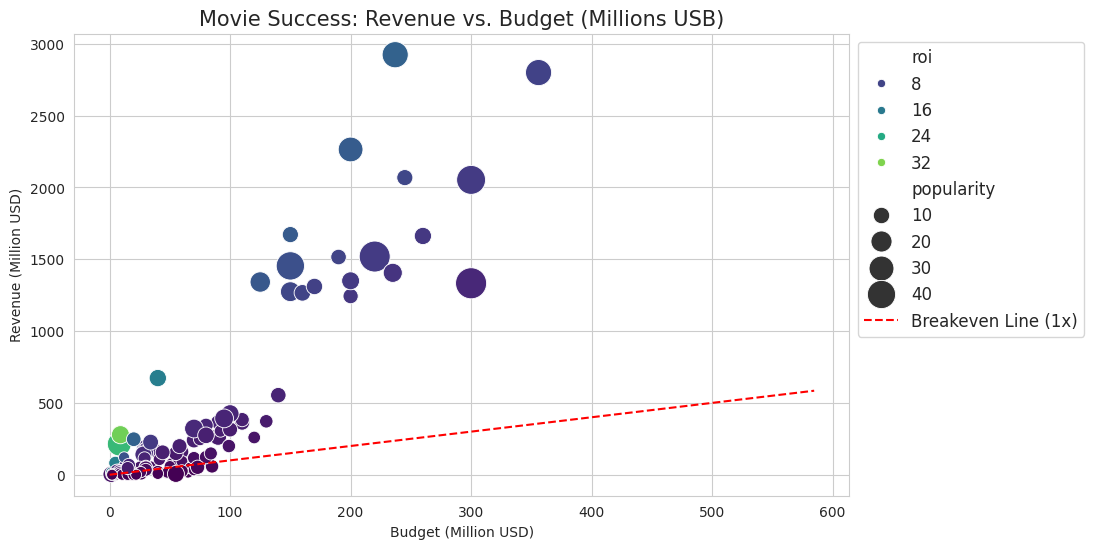

In [46]:
# Revenue vs. Budget Trends
df_rev_vs_budget = (
    df_final
    .select("budget_musd", "revenue_musd", "popularity", "roi")
    .toPandas()
)

stats = df_final.select(
    F.max("revenue_musd").alias("max_rev"),
    F.max("budget_musd").alias("max_bud")
).collect()[0]


plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Scatter plot
sns.scatterplot(
    data=df_rev_vs_budget,
    x='budget_musd',
    y='revenue_musd',
    size='popularity',
    hue='roi',
    palette='viridis',
    sizes=(50, 500)
)

# Add a diagonal line for breakeven (Revenue = Budget)
max_val = max(stats["max_rev"] or 0, stats["max_bud"] or 0)
plt.plot([0, max_val/5], [0, max_val/5], color='red', linestyle='--', label='Breakeven Line (1x)')

plt.title('Movie Success: Revenue vs. Budget (Millions USB)', fontsize=15)
plt.xlabel('Budget (Million USD)')
plt.ylabel('Revenue (Million USD)')
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=12)
plt.savefig("revenue_vs_budget.png", bbox_inches="tight", dpi=300)
plt.show()

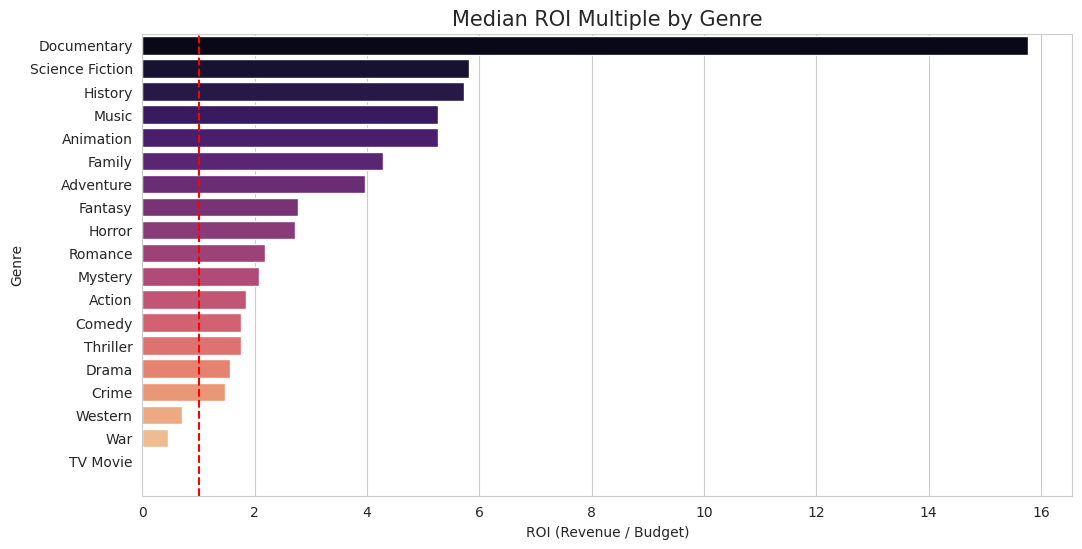

In [26]:
# ROI Distribution by Genre
df_genre_roi = (
    df_final.select("id", "genres", "roi")
    .filter(F.col("genres").isNotNull())
    .withColumn("genre", F.explode(F.split(F.col("genres"), "\\|")))
    .groupBy("genre")
    .agg(F.percentile_approx("roi", 0.5).alias("median_roi"))
    .orderBy(F.desc("median_roi"))
)

df_genre_roi_pd = df_genre_roi.toPandas().set_index("genre")["median_roi"]

plt.figure(figsize=(12, 6))
sns.barplot(
    x=df_genre_roi_pd.values,
    y=df_genre_roi_pd.index,
    hue=df_genre_roi_pd.index,
    palette='magma',
    legend=False
)
plt.title('Median ROI Multiple by Genre', fontsize=15)
plt.xlabel('ROI (Revenue / Budget)')
plt.ylabel('Genre')
plt.axvline(1, color='red', linestyle='--', label='Breakeven (1x)')
plt.show()

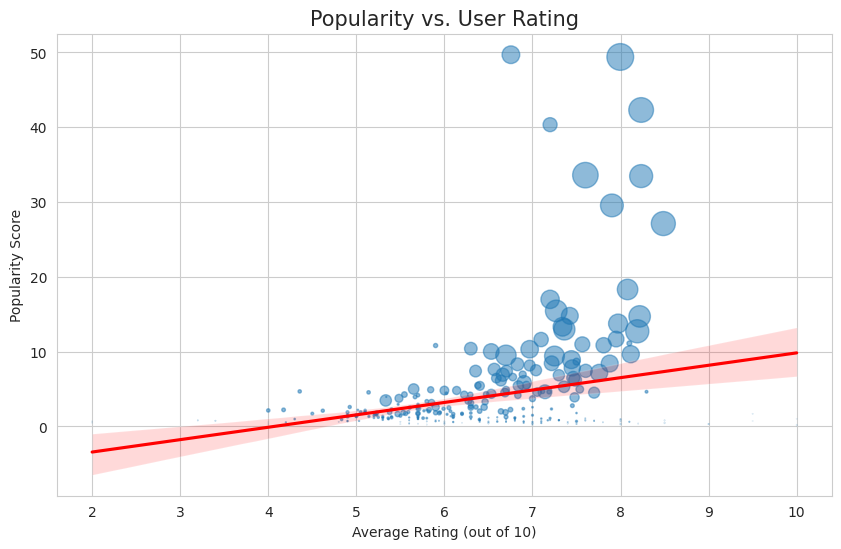

In [27]:
# Popularity vs. Rating
df_pop_vs_rating = (
    df_final
    .filter(
        (F.col("vote_count") > 0) &
        (F.col("vote_average").isNotNull()) &
        (F.col("popularity").isNotNull())
    )
    .select("vote_average", "popularity", "vote_count")
    .toPandas()
)

plt.figure(figsize=(10, 6))
sns.regplot(data=df_pop_vs_rating, x='vote_average', y='popularity',
            scatter_kws={'s':df_pop_vs_rating['vote_count']/100, 'alpha':0.5}, # Size based on vote count
            line_kws={'color':'red'})

plt.title('Popularity vs. User Rating', fontsize=15)
plt.xlabel('Average Rating (out of 10)')
plt.ylabel('Popularity Score')
plt.show()

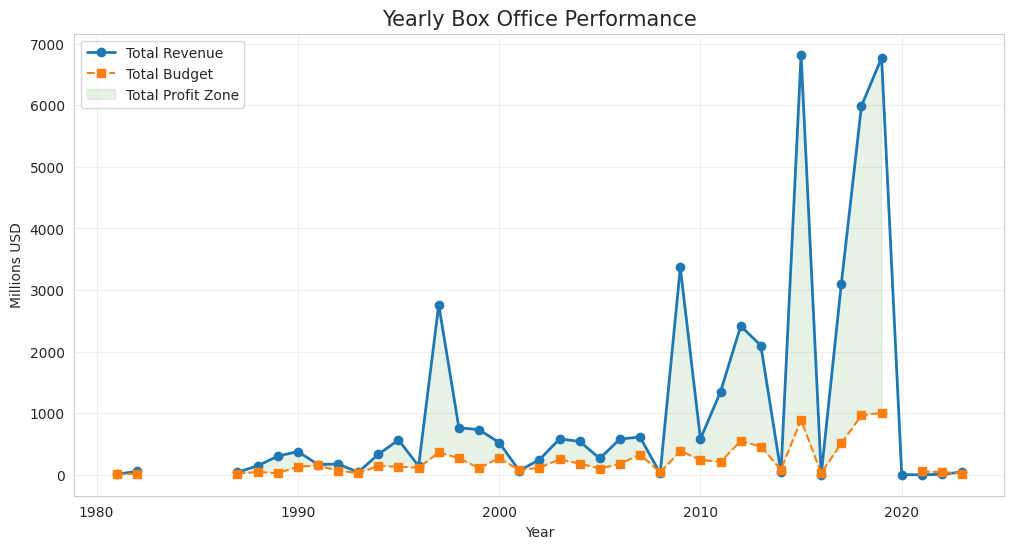

In [28]:
# Yearly Trends in Box Office Performance
# Extract Year and group
df_yearly_trends = (
    df_final
    .withColumn("year", F.year("release_date"))
    .filter(F.col("year").isNotNull())
    .groupBy("year")
    .agg(
        F.sum("revenue_musd").alias("revenue_musd"),
        F.sum("budget_musd").alias("budget_musd")
    )
    .orderBy("year")
)

df_yearly_trends_pd = df_yearly_trends.toPandas().set_index("year")

plt.figure(figsize=(12, 6))
plt.plot(df_yearly_trends_pd.index, df_yearly_trends_pd['revenue_musd'], marker='o', label='Total Revenue', linewidth=2)
plt.plot(df_yearly_trends_pd.index, df_yearly_trends_pd['budget_musd'], marker='s', label='Total Budget', linestyle='--')

plt.fill_between(
    df_yearly_trends_pd.index,
     df_yearly_trends_pd['budget_musd'],
     df_yearly_trends_pd['revenue_musd'],
     color='green',
     alpha=0.1,
     label='Total Profit Zone'
)

plt.title('Yearly Box Office Performance', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Millions USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

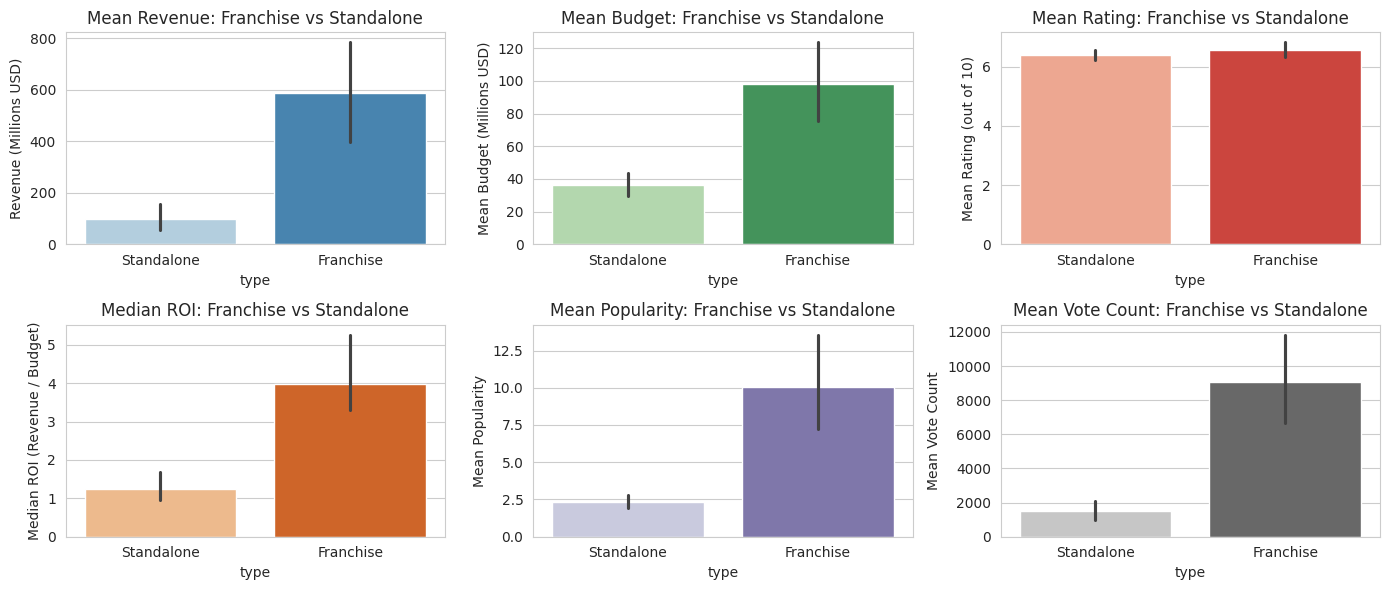

In [29]:
# Comparison of Franchise vs. Standalone Success
df_viz_spark = (
    df_final
    .withColumn("type",
        F.when(F.col("belongs_to_collection").isNull(), "Standalone")
        .otherwise("Franchise")
    )
    .select("type", "revenue_musd", "roi", "budget_musd", "popularity", "vote_average", "vote_count")
)

df_viz = df_viz_spark.toPandas()


fig, ax = plt.subplots(2, 3, figsize=(14, 6))

comp_plots = [
    {
        "y": "revenue_musd",
        "y_label": "Revenue (Millions USD)",
        "title": "Mean Revenue: Franchise vs Standalone",
        "palette": "Blues",
        "estimator": np.mean,
        "position": (0, 0)
    },
    {
        "y": "roi",
        "y_label": "Median ROI (Revenue / Budget)",
        "title": "Median ROI: Franchise vs Standalone",
        "palette": "Oranges",
        "estimator": np.median,
        "position": (1, 0)
    },
    {
        "y": "budget_musd",
        "y_label": "Mean Budget (Millions USD)",
        "title": "Mean Budget: Franchise vs Standalone",
        "palette": "Greens",
        "estimator": np.mean,
        "position": (0, 1)
    },
    {
        "y": "popularity",
        "y_label": "Mean Popularity",
        "title": "Mean Popularity: Franchise vs Standalone",
        "palette": "Purples",
        "estimator": np.mean,
        "position": (1, 1)
    },
    {
        "y": "vote_average",
        "y_label": "Mean Rating (out of 10)",
        "title": "Mean Rating: Franchise vs Standalone",
        "palette": "Reds",
        "estimator": np.mean,
        "position": (0, 2)
    },
    {
        "y": "vote_count",
        "y_label": "Mean Vote Count",
        "title": "Mean Vote Count: Franchise vs Standalone",
        "palette": "Greys",
        "estimator": np.mean,
        "position": (1, 2)
    }

]

for comp_plot in comp_plots:
    sns.barplot(
        data=df_viz,
        x='type',
        y=comp_plot['y'],
        estimator=comp_plot['estimator'],
        hue='type',
        ax=ax[comp_plot['position'][0], comp_plot['position'][1]],
        palette=comp_plot['palette'],
        legend=False
    )

    ax[comp_plot['position'][0], comp_plot['position'][1]].set_title(comp_plot['title'])
    ax[comp_plot['position'][0], comp_plot['position'][1]].set_ylabel(comp_plot['y_label'])


plt.tight_layout()
plt.show()